# Multitask Learning for Geometric Shape Classification and Counting



## Download and imports

In [2]:
!wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip

--2025-11-20 18:36:11--  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip [following]
--2025-11-20 18:36:13--  https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5544261 (5.3M) [application/zip]
Saving to: ‘data_gsn.zip’

data_gsn.zip        100%[===================>]   5.29M  23.0MB/s    in 0.2s    

2025-11-20 18:36:14 (23.0 MB/s) - ‘data_gsn.zip’ saved [5544261/5544261]



In [3]:
!pip install numpy
!pip install torch
!pip install matplotlib
!pip install scikit-learn
!pip install torchvision
!pip install pandas
!pip install seaborn
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 59.9 MB/s eta 0:00:00


In [4]:
import torch
from torchvision import transforms
import torch.nn as nn
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
from pathlib import Path
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.optim.lr_scheduler import ReduceLROnPlateau
import seaborn
from torchmetrics.classification import MulticlassF1Score
from collections import defaultdict
import time

torch.manual_seed(1)

## Code for ploting

In [5]:
def plot(epochs: int, train_losses, val_losses, val_accuracy, val_rmse):
    epochs_range = np.arange(1, epochs + 1)
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    ax1 = axes[0]
    ax1.plot(epochs_range, train_losses, label='Training Loss', color='blue')
    ax1.plot(epochs_range, val_losses, label='Validation Loss', color='red', linestyle='--')
    ax1.set_title('Training and validation losses')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('epochs')
    ax1.legend()
    ax1.grid(True)

    ax2 = axes[1]
    ax2.plot(epochs_range, np.array(val_accuracy) * 100, label='Validation Accuracy', color='green')
    ax2.set_title('Validation accuracy')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_xlabel('epochs')
    ax2.legend()
    ax2.grid(True)

    ax3 = axes[2]
    ax3.plot(epochs_range, val_rmse, label='Validation RMSE', color='orange')
    ax3.set_title('RMSE over epochs')
    ax3.set_ylabel('RMSE')
    ax3.set_xlabel('epochs')
    ax3.legend()
    ax3.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Data Preparation

I used rotations and flips since they change the images the most. The main issue I had was overfitting, so I wanted the data to be different almost every time the network trains.

In [6]:
class Dataset(Dataset):
    def __init__(self, data_dir: str, train: bool = True, transform=None):
        self.train = train
        self.data_dir = Path(data_dir)
        self.labels_df = pd.read_csv(self.data_dir / "labels.csv")

        if train:
            self.labels_df = self.labels_df.iloc[:9000].reset_index(drop=True)
            self.transform = transforms.ToTensor()
        else:
            self.labels_df = self.labels_df.iloc[9000:].reset_index(drop=True)
            self.transform = transforms.ToTensor()


        array = []
        self.class_mapping = {}

        for i, j in combinations(range(6), 2):
            for ai in range(1, 10):
                for aj in range(1, 10):
                    if ai + aj == 10:
                        array.append(10**i * ai + 10**j * aj)
        array = sorted(array)

        it = 0
        for i in array:
            self.class_mapping[i] = it
            it += 1

    def __len__(self):
        return len(self.labels_df)

    def get_mapping(self, labels):
        key = sum(int(labels[i].item()) * (10 ** i) for i in range(6))
        return self.class_mapping[key]

    def __getitem__(self, i):
        row = self.labels_df.iloc[i]

        img_path = self.data_dir / row['name']
        image = Image.open(img_path).convert("L")
        vals = row[1:].values.astype(float)
        order = [0, 1, 2, 3, 4, 5]
        if self.train:
            r = random.random()
            if r < 0.125:
                image = TF.rotate(image, angle=90, interpolation=TF.InterpolationMode.NEAREST, expand=True)
                order = [0, 1, 3, 4, 5, 2]
                vals = vals[order]
            elif r < 0.25:
                image = TF.rotate(image, angle=180, interpolation=TF.InterpolationMode.NEAREST, expand=True)
                order = [0, 1, 4, 5, 2, 3]
                vals = vals[order]
            elif r < 0.375:
                image = TF.rotate(image, angle=-90, interpolation=TF.InterpolationMode.NEAREST, expand=True)
                order = [0, 1, 5, 2, 3, 4]
                vals = vals[order]
            elif r < 0.5:
                image = TF.rotate(image, angle=-180, interpolation=TF.InterpolationMode.NEAREST, expand=True)
                order = [0, 1, 4, 5, 2, 3]
                vals = vals[order]
            if random.random() < 0.5:
                image = TF.hflip(image)
                order = [0, 1, 2, 5, 4, 3]
                vals = vals[order]
            if random.random() < 0.5:
                image = TF.vflip(image)
                order = [0, 1, 4, 3, 2, 5]
                vals = vals[order]

        labels = torch.tensor(vals, dtype=torch.float32)

        image = self.transform(image)
        cls = torch.tensor(int(self.get_mapping(labels)), dtype=torch.long)

        return image, labels, cls

## Model Definition

I kept the heads simple since, with this backbone, any changes only made classification worse. The only success I had was applying heavy dropout in the classification head to battle the overfitting.


In [7]:
class Net(nn.Module):
    def __init__(self, drop1 = 0.5, drop2 = 0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
        )

        self.head_cls = nn.Sequential(
            nn.Dropout(p=drop1),
            nn.Linear(256, 135),
            nn.LogSoftmax(dim=1)
        )

        self.head_cnt = nn.Sequential(
            nn.Dropout(p=drop2),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        features = self.backbone(x)
        log_probs = self.head_cls(features)
        counts = self.head_cnt(features)
        return log_probs, counts

## Training and Evaluation Logic

The `MultiTaskTrainer` class defines the entire training and evaluation pipeline for the multi-task learning model. It automatically saves the best model to `best_model.pth`, which the `report` function later loads to calculate all the required metrics.


In [8]:
class MultiTaskTrainer:
    def __init__(self) -> None:
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.trainset = Dataset("data", train=True)
        self.trainloader = DataLoader(
            self.trainset, batch_size=64, shuffle=True, num_workers=2
        )

        self.testset = Dataset("data", train=False)
        self.testloader = DataLoader(
            self.testset  , batch_size=1000, shuffle=False, num_workers=2
        )

        self.train_losses = []
        self.val_losses = []
        self.val_accuracies  = []
        self.val_RMSE = []

        self.cls_criterion = nn.NLLLoss()
        self.cnt_criterion = nn.SmoothL1Loss()
        self.mse_criterion = nn.MSELoss()
        self.mae_criterion = nn.L1Loss()

    def train_epoch(self, net, optimizer, lambda_cls, lambda_cnt, epoch) -> None:
        net.train()
        total_train_loss = 0.0

        for images, labels, cls in self.trainloader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            cls = cls.to(self.device)

            optimizer.zero_grad()

            log_probs, counts = net(images)
            loss_cls = self.cls_criterion(log_probs, cls)
            loss_cnt = self.cnt_criterion(counts, labels)

            loss = lambda_cls * loss_cls + lambda_cnt * loss_cnt
            loss.backward()

            optimizer.step()
            total_train_loss += loss.item()

        self.train_losses.append(total_train_loss / len(self.trainloader))

    def test(self, net, lambda_cls, lambda_cnt, epoch) -> list[float]:
        net.eval()
        total_val_loss = 0.0
        total_val_rmse_loss = 0.0
        correct_cls = 0

        with torch.no_grad():
            images, labels, cls = next(iter(self.testloader))

            images = images.to(self.device)
            labels = labels.to(self.device)
            cls = cls.to(self.device)

            log_probs, counts = net(images)

            loss_cls = self.cls_criterion(log_probs, cls)
            loss_cnt = self.cnt_criterion(counts, labels)
            loss = lambda_cls * loss_cls + lambda_cnt * loss_cnt

            rmse_loss = torch.sqrt(self.mse_criterion(counts, labels))
            correct_cls = (log_probs.argmax(dim=1) == cls).sum().item()

            avg_loss = loss.item()
            self.val_losses.append(avg_loss)
            accuracy = correct_cls / len(cls)
            self.val_accuracies.append(accuracy)
            rmse = rmse_loss.item()
            self.val_RMSE.append(rmse)

            print("\n--- Epoch", epoch+1, "---")
            print(f"Accuracy: {accuracy * 100:.2f}%")
            print(f"Loss: {avg_loss:.4f}")
            print(f"RMSE: {rmse:.4f}")

            return [avg_loss, accuracy, rmse]

    def train(
        self,
        net: nn.Module,
        epochs: int = 100,
        lr: float = 1e-3,
        lambda_cls = 0,
        lambda_cnt = 0,
        patience: int = 10
    ) -> int:

        net = net.to(self.device)
        optimizer = optim.Adam(net.parameters(), lr=lr)

        best_loss = float('inf')
        patience_counter = 0
        ep = 0
        start_time = time.time()

        for epoch in range(epochs):
            ep += 1
            self.train_epoch(net, optimizer, lambda_cls, lambda_cnt, epoch)
            [avg_loss, accuracy, rmse] = self.test(net, lambda_cls, lambda_cnt, epoch)

            if avg_loss < best_loss:
                best_loss = avg_loss
                torch.save(net.state_dict(), "best_model.pth")
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter == patience:
                break
                print(lambda_cls, lambda_cnt)
        end_time = time.time()
        runtime_seconds = end_time - start_time
        print(f"Czas działania: {runtime_seconds:.2f} sekund")

        return ep

    def report(self, net: nn.Module):
        net = net.to(self.device)
        net.load_state_dict(torch.load("best_model.pth"))
        net.eval()

        images, labels, cls = next(iter(self.testloader))

        images = images.to(self.device)
        labels = labels.to(self.device)
        cls = cls.to(self.device)

        log_probs, counts = net(images)
        correct_cls = (log_probs.argmax(dim=1) == cls).sum().item()

        per_pair_mapping = defaultdict(lambda: [0, 0])
        for label, correct, pred in zip(labels, cls, log_probs.argmax(dim=1)):
            binary_vector = (label != 0).long()
            key = tuple(binary_vector.tolist())

            per_pair_mapping[key][1] += 1

            if pred == correct:
                per_pair_mapping[key][0] += 1

        accuracy = correct_cls / len(cls)
        metric = MulticlassF1Score(num_classes=135, average='macro').to(self.device)
        f1 = metric(log_probs.argmax(dim=1), cls)

        rmse_overall = torch.sqrt(self.mse_criterion(counts, labels)).item()
        mae_overall = self.mae_criterion(counts, labels).item()

        print("(a) Classification (135-way) \n")
        print(f"Top-1 Accuracy: {accuracy * 100:.2f}%")
        print(f"Top-1 Accuracy: {accuracy * 100:.2f}%")
        print(f"Macro F1: {f1.item():.4f}\n")


        names = ["squares","circles","up","right","down","left"]
        print("Per-pair accuracy:")
        for key, value in per_pair_mapping.items():
            name_parts = []
            for i in range(len(key)):
                if key[i] == 1:
                    name_parts.append(names[i])
            name_parts.sort()
            combined_name = " + ".join(name_parts)
            print(f"  {combined_name}: {value[0] / value[1] * 100:.2f}%")

        print("\n(b) Regression (6-D counts) \n")
        print(f"Overall RMSE: {rmse_overall:.4f}")
        print(f"Overall MAE: {mae_overall:.4f}\n")

        print("RMSE per class:")
        for i, name in enumerate(names):
            rmse_class = torch.sqrt(self.mse_criterion(counts[:, i], labels[:, i])).item()
            print(f"  {name}: {rmse_class:.4f}")

        print("\nMAE per class:")
        for i, name in enumerate(names):
            mae_class = self.mae_criterion(counts[:, i], labels[:, i]).item()
            print(f"  {name}: {mae_class:.4f}")




## Experiment 1: Classification Only


--- Epoch 1 ---
Accuracy: 1.00%
Loss: 4.6903
RMSE: 3.0883

--- Epoch 2 ---
Accuracy: 0.80%
Loss: 4.6461
RMSE: 3.0976

--- Epoch 3 ---
Accuracy: 2.80%
Loss: 4.1485
RMSE: 3.0527

--- Epoch 4 ---
Accuracy: 3.90%
Loss: 3.9693
RMSE: 3.0281

--- Epoch 5 ---
Accuracy: 4.30%
Loss: 3.8343
RMSE: 3.0073

--- Epoch 6 ---
Accuracy: 4.50%
Loss: 3.7488
RMSE: 3.0437

--- Epoch 7 ---
Accuracy: 5.20%
Loss: 3.7333
RMSE: 2.9984

--- Epoch 8 ---
Accuracy: 6.60%
Loss: 3.6275
RMSE: 3.0309

--- Epoch 9 ---
Accuracy: 12.60%
Loss: 3.2346
RMSE: 2.9833

--- Epoch 10 ---
Accuracy: 14.70%
Loss: 2.9369
RMSE: 3.0267

--- Epoch 11 ---
Accuracy: 19.10%
Loss: 2.6499
RMSE: 3.0496

--- Epoch 12 ---
Accuracy: 20.50%
Loss: 2.5051
RMSE: 3.0431

--- Epoch 13 ---
Accuracy: 21.30%
Loss: 2.3508
RMSE: 3.0736

--- Epoch 14 ---
Accuracy: 25.90%
Loss: 2.1853
RMSE: 3.0937

--- Epoch 15 ---
Accuracy: 29.90%
Loss: 2.0948
RMSE: 3.0986

--- Epoch 16 ---
Accuracy: 32.90%
Loss: 1.9090
RMSE: 3.1041

--- Epoch 17 ---
Accuracy: 36.10%
Loss: 

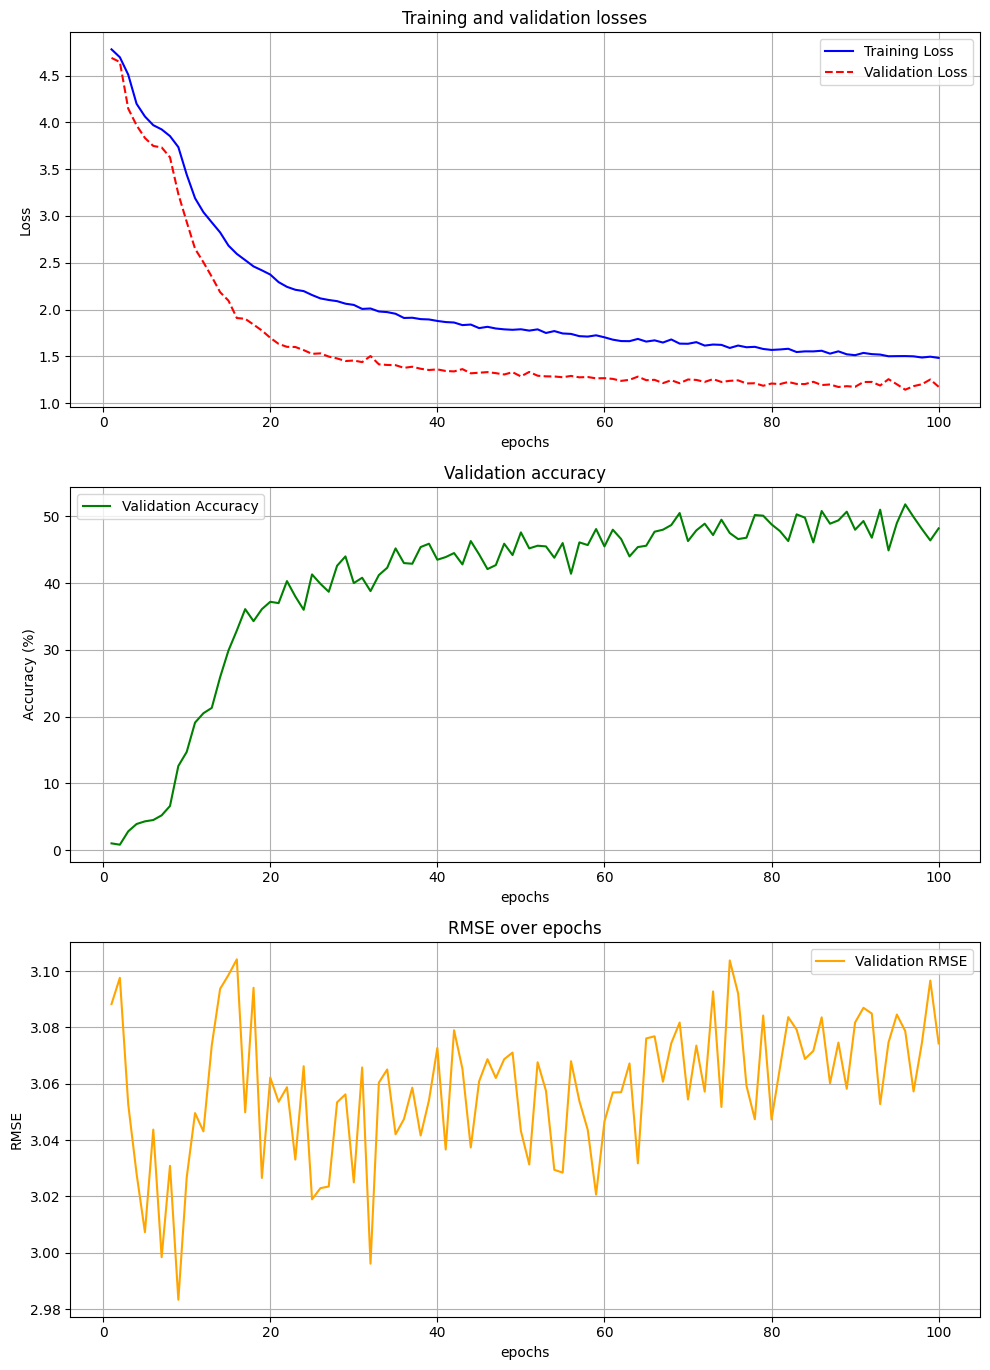

(a) Classification (135-way) 

Top-1 Accuracy: 51.80%
Top-1 Accuracy: 51.80%
Macro F1: 0.4725

Per-pair accuracy:
  right + up: 53.85%
  left + squares: 47.83%
  down + right: 50.00%
  circles + up: 56.00%
  right + squares: 55.56%
  down + squares: 57.81%
  left + up: 49.23%
  down + left: 53.33%
  squares + up: 52.86%
  circles + squares: 58.73%
  circles + left: 51.56%
  left + right: 42.42%
  circles + down: 42.62%
  down + up: 50.75%
  circles + right: 53.52%

(b) Regression (6-D counts) 

Overall RMSE: 3.0787
Overall MAE: 2.1645

RMSE per class:
  squares: 2.3227
  circles: 2.9644
  up: 4.1507
  right: 2.9306
  down: 2.7341
  left: 3.0651

MAE per class:
  squares: 1.7143
  circles: 2.3696
  up: 2.8522
  right: 1.8901
  down: 2.1266
  left: 2.0340


In [9]:
net = Net(0.7, 0)
trainer = MultiTaskTrainer()
epochs = trainer.train(net, epochs = 100, lambda_cls = 1, lambda_cnt = 0, patience = 10)
plot(epochs, trainer.train_losses, trainer.val_losses, trainer.val_accuracies , trainer.val_RMSE)
trainer.report(net)

## Experiment 2: Regression Only


--- Epoch 1 ---
Accuracy: 0.10%
Loss: 1.0530
RMSE: 2.1080

--- Epoch 2 ---
Accuracy: 0.40%
Loss: 0.4481
RMSE: 1.1223

--- Epoch 3 ---
Accuracy: 0.10%
Loss: 0.3567
RMSE: 0.9791

--- Epoch 4 ---
Accuracy: 0.10%
Loss: 0.3119
RMSE: 0.8938

--- Epoch 5 ---
Accuracy: 0.10%
Loss: 0.2916
RMSE: 0.8605

--- Epoch 6 ---
Accuracy: 0.10%
Loss: 0.2707
RMSE: 0.8294

--- Epoch 7 ---
Accuracy: 0.10%
Loss: 0.2590
RMSE: 0.8075

--- Epoch 8 ---
Accuracy: 0.10%
Loss: 0.2639
RMSE: 0.8108

--- Epoch 9 ---
Accuracy: 0.10%
Loss: 0.2574
RMSE: 0.8015

--- Epoch 10 ---
Accuracy: 0.10%
Loss: 0.2238
RMSE: 0.7337

--- Epoch 11 ---
Accuracy: 0.10%
Loss: 0.2142
RMSE: 0.7187

--- Epoch 12 ---
Accuracy: 0.10%
Loss: 0.2130
RMSE: 0.7132

--- Epoch 13 ---
Accuracy: 0.10%
Loss: 0.2118
RMSE: 0.7094

--- Epoch 14 ---
Accuracy: 0.20%
Loss: 0.2013
RMSE: 0.6896

--- Epoch 15 ---
Accuracy: 0.20%
Loss: 0.1915
RMSE: 0.6714

--- Epoch 16 ---
Accuracy: 0.20%
Loss: 0.1959
RMSE: 0.6803

--- Epoch 17 ---
Accuracy: 0.20%
Loss: 0.1885
RM

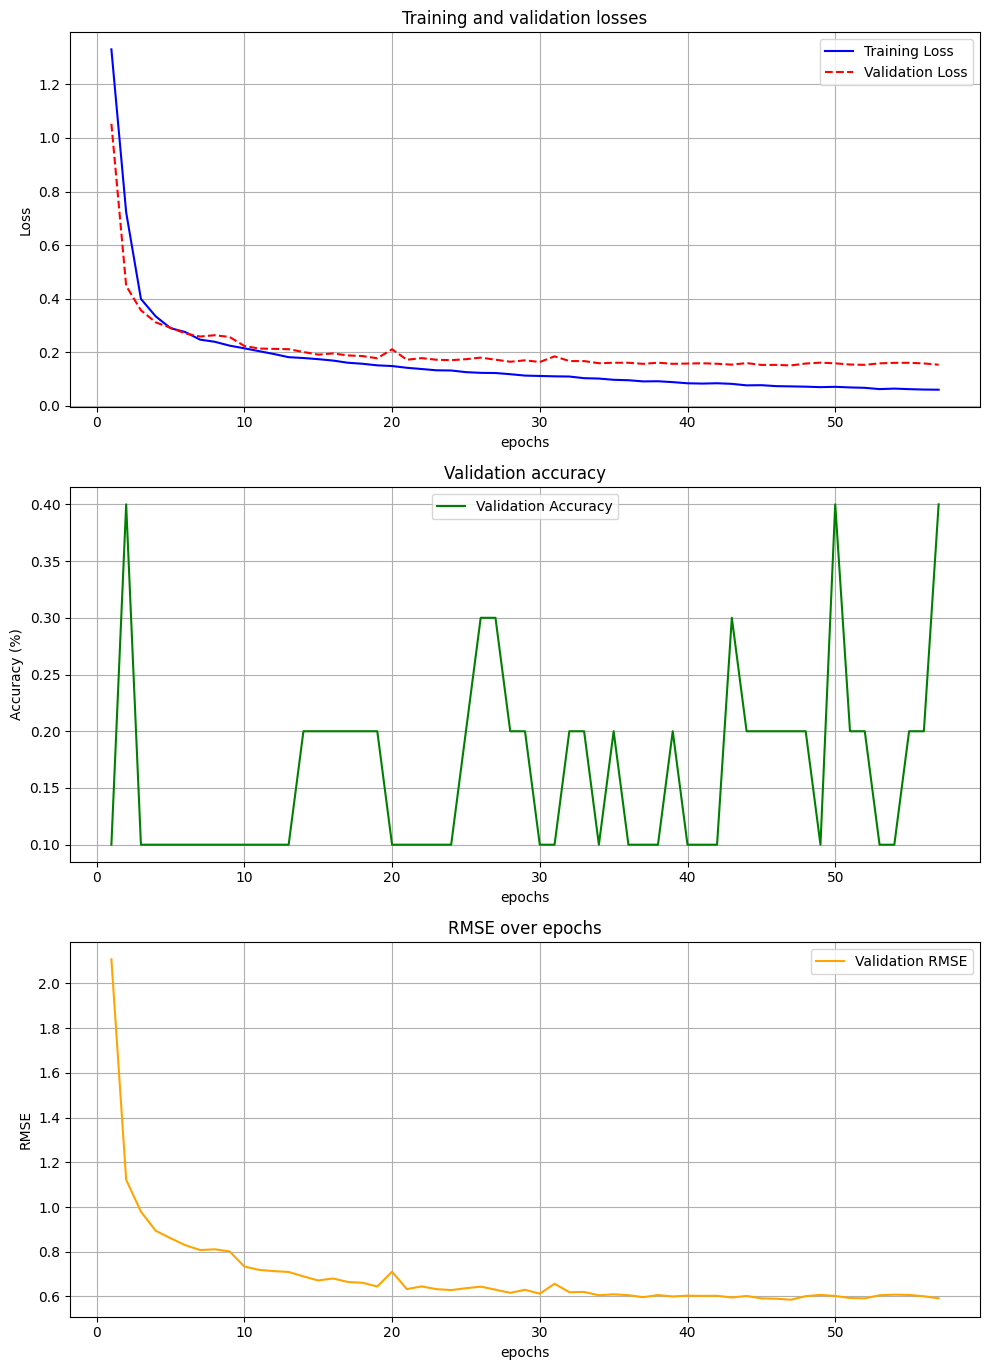

(a) Classification (135-way) 

Top-1 Accuracy: 0.20%
Top-1 Accuracy: 0.20%
Macro F1: 0.0001

Per-pair accuracy:
  right + up: 0.00%
  left + squares: 0.00%
  down + right: 0.00%
  circles + up: 0.00%
  right + squares: 0.00%
  down + squares: 1.56%
  left + up: 0.00%
  down + left: 0.00%
  squares + up: 0.00%
  circles + squares: 0.00%
  circles + left: 0.00%
  left + right: 1.52%
  circles + down: 0.00%
  down + up: 0.00%
  circles + right: 0.00%

(b) Regression (6-D counts) 

Overall RMSE: 0.5853
Overall MAE: 0.3905

RMSE per class:
  squares: 0.4885
  circles: 0.5372
  up: 0.6041
  right: 0.5979
  down: 0.6304
  left: 0.6392

MAE per class:
  squares: 0.3299
  circles: 0.3532
  up: 0.4167
  right: 0.3799
  down: 0.4230
  left: 0.4406


In [10]:
net = Net(0.7, 0)
trainer = MultiTaskTrainer()
epochs = trainer.train(net, epochs = 100, lambda_cls = 0, lambda_cnt = 1, patience = 10)
plot(epochs, trainer.train_losses, trainer.val_losses, trainer.val_accuracies , trainer.val_RMSE)
trainer.report(net)

## Experiment 3: 	Multitask: λ_cnt = 1


--- Epoch 1 ---
Accuracy: 1.90%
Loss: 5.6379
RMSE: 2.5380

--- Epoch 2 ---
Accuracy: 7.30%
Loss: 4.7900
RMSE: 2.1671

--- Epoch 3 ---
Accuracy: 13.50%
Loss: 3.8924
RMSE: 1.6124

--- Epoch 4 ---
Accuracy: 22.80%
Loss: 2.8437
RMSE: 1.1021

--- Epoch 5 ---
Accuracy: 29.00%
Loss: 2.4044
RMSE: 0.9947

--- Epoch 6 ---
Accuracy: 33.00%
Loss: 2.2225
RMSE: 0.9415

--- Epoch 7 ---
Accuracy: 32.30%
Loss: 2.1173
RMSE: 0.9078

--- Epoch 8 ---
Accuracy: 35.90%
Loss: 2.0485
RMSE: 0.9049

--- Epoch 9 ---
Accuracy: 33.00%
Loss: 1.9925
RMSE: 0.8907

--- Epoch 10 ---
Accuracy: 36.90%
Loss: 1.8989
RMSE: 0.8138

--- Epoch 11 ---
Accuracy: 34.60%
Loss: 1.9013
RMSE: 0.8339

--- Epoch 12 ---
Accuracy: 36.10%
Loss: 1.8608
RMSE: 0.8206

--- Epoch 13 ---
Accuracy: 37.00%
Loss: 1.8261
RMSE: 0.7939

--- Epoch 14 ---
Accuracy: 36.40%
Loss: 1.7884
RMSE: 0.7810

--- Epoch 15 ---
Accuracy: 41.10%
Loss: 1.7439
RMSE: 0.7721

--- Epoch 16 ---
Accuracy: 41.00%
Loss: 1.7072
RMSE: 0.7607

--- Epoch 17 ---
Accuracy: 39.10%


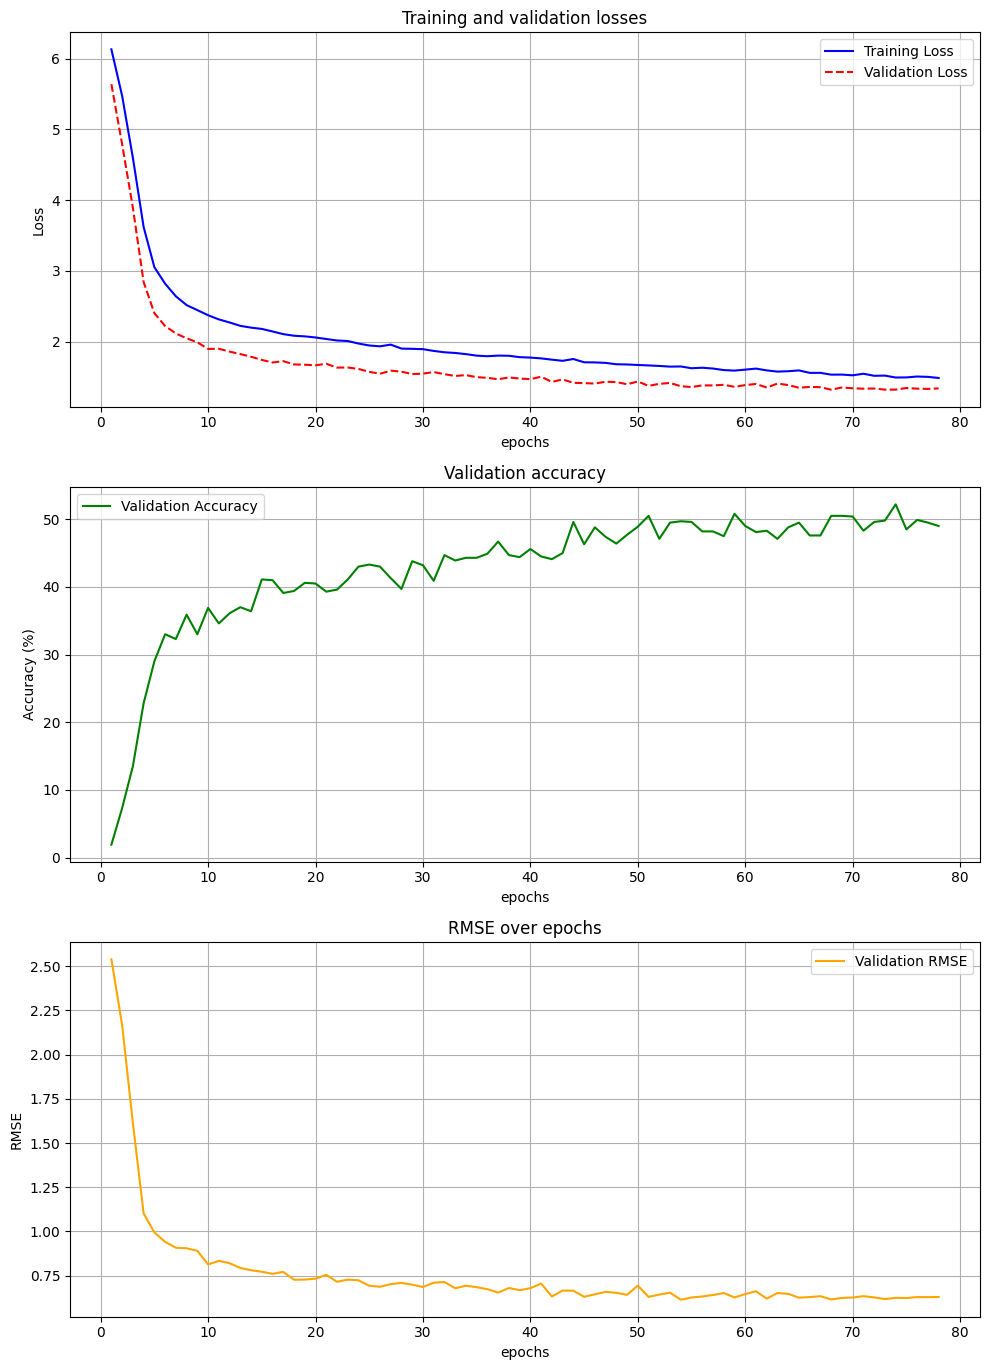

(a) Classification (135-way) 

Top-1 Accuracy: 50.50%
Top-1 Accuracy: 50.50%
Macro F1: 0.4663

Per-pair accuracy:
  right + up: 47.69%
  left + squares: 53.62%
  down + right: 38.71%
  circles + up: 56.00%
  right + squares: 60.32%
  down + squares: 57.81%
  left + up: 50.77%
  down + left: 50.67%
  squares + up: 40.00%
  circles + squares: 61.90%
  circles + left: 56.25%
  left + right: 33.33%
  circles + down: 52.46%
  down + up: 56.72%
  circles + right: 42.25%

(b) Regression (6-D counts) 

Overall RMSE: 0.6156
Overall MAE: 0.3914

RMSE per class:
  squares: 0.5774
  circles: 0.5400
  up: 0.6106
  right: 0.6758
  down: 0.6221
  left: 0.6576

MAE per class:
  squares: 0.4097
  circles: 0.3249
  up: 0.3790
  right: 0.4361
  down: 0.3841
  left: 0.4148


In [11]:
net = Net(0.7, 0)
trainer = MultiTaskTrainer()
epochs = trainer.train(net, epochs = 100, lambda_cls = 1, lambda_cnt = 1, patience = 10)
plot(epochs, trainer.train_losses, trainer.val_losses, trainer.val_accuracies , trainer.val_RMSE)
trainer.report(net)